In [17]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow

In [31]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from google.colab import output
from base64 import b64decode

In [19]:
uploaded=files.upload()
file_name=list(uploaded.keys())[0]
print("Uploaded: ",file_name)

Saving image.jpg to image (1).jpg
Uploaded:  image (1).jpg


In [35]:
model=YOLO('yolov8n.pt')

In [21]:
results=model(file_name)
annotated=results[0].plot()


image 1/1 /content/image (1).jpg: 608x640 1 person, 324.2ms
Speed: 21.5ms preprocess, 324.2ms inference, 4.3ms postprocess per image at shape (1, 3, 608, 640)


(np.float64(-0.5), np.float64(197.5), np.float64(182.5), np.float64(-0.5))

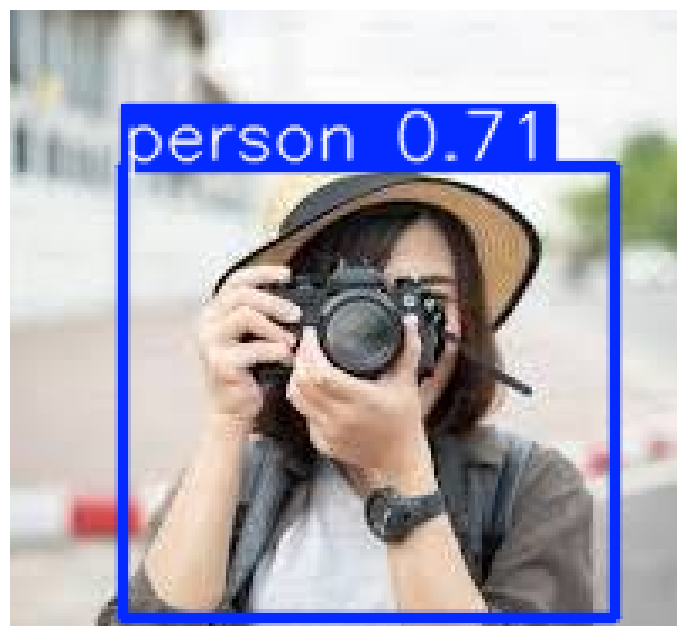

In [22]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
plt.axis("off")


# **VIDEO DETECTION**

In [23]:
uploaded=files.upload()
video_path=list(uploaded.keys())[0]
print("Uploaded: ",video_path)

Saving lovely best friend #couple #trinhhyy #giaitri #dance #love #shortvideo #funny #short #cute.mp4 to lovely best friend #couple #trinhhyy #giaitri #dance #love #shortvideo #funny #short #cute (1).mp4
Uploaded:  lovely best friend #couple #trinhhyy #giaitri #dance #love #shortvideo #funny #short #cute (1).mp4


In [24]:
output_path="output_detected.mp4"
cap=cv2.VideoCapture(video_path)
width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps=int(cap.get(cv2.CAP_PROP_FPS)) or 25.0
fourcc=cv2.VideoWriter_fourcc(*'mp4v')
out=cv2.VideoWriter(output_path,fourcc,fps,(width,height))

frame_count=0
while True:
  ret,frame=cap.read()
  if not ret:
    break
  results=model(frame)
  annotated=results[0].plot()
  out.write(annotated)
  frame_count+=1
  if frame_count%100==0:
    print(f"processed {frame_count} frames")
  cap.release()
  out.release()
  print("Video Saved:",output_path)
  files.download(output_path)



0: 640x384 4 persons, 2 cell phones, 167.2ms
Speed: 4.2ms preprocess, 167.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)
Video Saved: output_detected.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **WEBCAM**

In [42]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from google.colab import output
from base64 import b64decode


model=YOLO('yolov8n.pt')



def take_photo(filename="snapshot.jpg"):
  js="""
  async function takephoto(){
    const div=document.createElement("div");
    const capture=document.createElement("button");
    capture.textContent="Capture";
    div.appendChild(capture);

    const video=document.createElement("video");
    video.style.display="block";
    const stream=await navigator.mediaDevices.getUserMedia({video:true});
    document.body.appendChild(div);
    video.srcObject=stream;
    await video.play();

    //resize window
    google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);

    //wait for capture button
    await new Promise((resolve)=>capture.onclick=resolve);

    const canvas=document.createElement('canvas');
    canvas.width=video.videoWidth;
    canvas.height=video.videoHeight;
    canvas.getContext('2d').drawImage(video,0,0);
    stream.getTracks().forEach(track=>track.stop());
    const imgData=canvas.toDataURL('image/jpeg').split(',')[1];
    div.remove();
    return imgData;
  }
  takephoto();

  """
  data=output.eval_js(js)
  with open(filename,"wb")as f:
    f.write(b64decode(data))
  return filename
  filename=take_photo('snapshot.jpg')
  print("Captured: ",filename)

  results=model(filename)
  annotated=results[0].plot()
  plt.figure(figsize=(12,8))
  plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

# **YOLO TRAINING**

In [44]:
# download and save as coco128.zip
!curl -L "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip" -o coco128.zip

# unzip into dataset/ folder
!unzip -q coco128.zip -d dataset

# check contents
!ls dataset/coco128


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6819k  100 6819k    0     0  13.5M      0 --:--:-- --:--:-- --:--:-- 13.5M
images	labels	LICENSE  README.txt


In [46]:
%%writefile dataset/coco128/data.yaml
path:dataset/coco128
train:images/train2017
val:images/val2017

nc:80

names:
  0:Person

  1:Bicycle

  2:Car

  3:Motorcycle

  4:Airplane

  5:Bus

  6:Train

  7:Truck

  8:Boat

  9:Traffic light

  10:Fire hydrant

  11:Stop sign

  12:Parking meter

  13:Bench

  14:Bird

  15:Cat

  16:Dog

  17:Horse

  18:Sheep

  19:Cow

  20:Elephant

  21:Bear

  22:Zebra

  23:Giraffe

  24:Backpack

  25:Umbrella



  26:Handbag

  27:Tie

  28:Suitcase

  29:Frisbee

  30:Skis

  31:Snowboard

  32:Sports ball

  33:Kite

  34:Baseball bat

  35:Baseball glove

  36:Skateboard

  37:Surfboard

  38:Tennis racket

  39:Bottle

  40:Wine glass

  41:Cup

  42:Fork

  43:Knife

  44:Spoon

  45:Bowl

  46:Banana

  47:Apple

  48:Sandwich

  49:Orange

  50:Broccoli

  51:Carrot

  52:Hot dog

  53:Pizza

  54:Donut

  55:Cake

  56:Chair

  57:Couch

  58:Potted plant

  59:Bed

  60:Dining table

  61:Toilet

  62:TV

  63:Laptop

  64:Mouse

  65:Remote

  66:Keyboard

  67:Cell phone

  68:Microwave

  69:Oven

  70:Toaster

  71:Sink

  72:Refrigerator

  73:Book

  74:Clock

  75:Vase

  76:Scissors

  77:Teddy bear

  78:Hair drier

  79:Toothbrush





Overwriting dataset/coco128/data.yaml


In [48]:
model=YOLO('yolov8n.pt')
model.train(
    data="/content/dataset/coco128/data.yaml",
    epochs=10,
    imgsz=640,
    project="YOLO_Training",
    name="yolov8n_custom"
)

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/coco128/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

RuntimeError: Dataset '/content/dataset/coco128/data.yaml' error ❌ mapping values are not allowed in this context
  in "<unicode string>", line 7, column 6

In [ ]:
gx -b